In [1]:
from langgraph.graph import StateGraph ,START , END
from typing import TypedDict


In [2]:
from typing import TypedDict

class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    result: str 

In [3]:
def calculate_bmi(state: BMIState):
    bmi = state["weight"] / (state["height"] ** 2)

    return {
        "bmi": round(bmi, 2)
    }

In [4]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [5]:
def getllmresponse(state: BMIState):

    prompt = f"""
    You are a professional fitness and nutrition coach.

    User Details:
    Weight: {state['weight']} kg
    Height: {state['height']} m
    BMI: {state['bmi']}

    Based on the BMI:
    1. Tell the BMI category.
    2. Explain what it means.
    3. Give diet suggestions.
    4. Give exercise suggestions.
    5. Mention precautions.
    6. Keep the answer simple and motivating.
    """

    response = llm.invoke(prompt)

    return {
        "result": response.content
    }

In [6]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [7]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(BMIState)

# Nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("llm_response", getllmresponse)

# Edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "llm_response")
graph.add_edge("llm_response", END)

workflow = graph.compile()

In [8]:
result = workflow.invoke({
    "weight": 70,
    "height": 1.75
})

print(result["result"])

**Your BMI Category: Normal**

Don't worry; you're doing great! A BMI of 22.86 is considered normal. This means your weight is proportional to your height, and you're likely at a low risk of health problems related to being underweight or overweight.

**What it means:**

Having a normal BMI is fantastic news! It shows that you're likely to have a healthy weight, and your body is functioning well. This is a great foundation for achieving your fitness goals.

**Diet Suggestions:**

To maintain your healthy weight, focus on:

1. **Balanced Eating:** Eat a variety of foods, including lean proteins (chicken, fish, tofu), complex carbs (brown rice, whole grains), and healthy fats (nuts, seeds, avocado).
2. **Hydration:** Drink plenty of water throughout the day to stay energized and focused.
3. **Portion Control:** Pay attention to serving sizes and eat until you're satisfied, not stuffed.
4. **Meal Frequency:** Aim for 3 main meals and 2-3 snacks in between to keep your metabolism going.

*

In [9]:
print(result)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'result': "**Your BMI Category: Normal**\n\nDon't worry; you're doing great! A BMI of 22.86 is considered normal. This means your weight is proportional to your height, and you're likely at a low risk of health problems related to being underweight or overweight.\n\n**What it means:**\n\nHaving a normal BMI is fantastic news! It shows that you're likely to have a healthy weight, and your body is functioning well. This is a great foundation for achieving your fitness goals.\n\n**Diet Suggestions:**\n\nTo maintain your healthy weight, focus on:\n\n1. **Balanced Eating:** Eat a variety of foods, including lean proteins (chicken, fish, tofu), complex carbs (brown rice, whole grains), and healthy fats (nuts, seeds, avocado).\n2. **Hydration:** Drink plenty of water throughout the day to stay energized and focused.\n3. **Portion Control:** Pay attention to serving sizes and eat until you're satisfied, not stuffed.\n4. **Meal Frequency:** Aim for 3

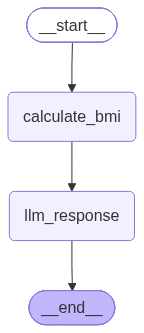

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [11]:
from pydantic import BaseModel , Field
from dotenv import load_dotenv

In [12]:
class feedbacksession(BaseModel):
    feedback : str 
    score : int 

In [13]:
structured_output = llm.with_structured_output(feedbacksession)

In [14]:
essays = """# Who is Mahatma Gandhi?

Mahatma Gandhi, whose full name was Mohandas Karamchand Gandhi, was one of the greatest leaders in the history of India. He is known as the "Father of the Nation" because of his significant role in India's struggle for independence from British rule. Gandhi was born on October 2, 1869, in Porbandar, Gujarat.

Gandhi studied law in England and later worked in South Africa, where he experienced racial discrimination. These experiences inspired him to fight against injustice through peaceful means. He believed in the principles of truth (*Satya*) and non-violence (*Ahimsa*), which became the foundation of his movements.

After returning to India, Gandhi led several important movements, including the Non-Cooperation Movement, the Civil Disobedience Movement, and the Quit India Movement. One of his most famous protests was the Dandi Salt March in 1930, where he opposed the British salt tax through peaceful protest. His leadership inspired millions of Indians to join the freedom struggle.

Gandhi believed that real strength comes from peace, honesty, and self-discipline. He encouraged people to wear *khadi* (hand-spun cloth), promote village industries, and live simple lives. His teachings continue to inspire people around the world to solve conflicts without violence.

On January 30, 1948, Mahatma Gandhi was assassinated in New Delhi. Although he is no longer alive, his ideas and values remain influential across the world. Every year, his birthday, October 2, is celebrated as Gandhi Jayanti in India and as the International Day of Non-Violence by the United Nations.

In conclusion, Mahatma Gandhi was a remarkable leader who showed that courage, truth, and non-violence can bring about great social and political change. His life continues to inspire people to work for peace, justice, and equality.
"""

In [15]:
prompts = f"give  me feedback and score of this essays here is {essays}"

structured_output.invoke(prompts)


feedbacksession(feedback="This essay provides a clear and concise overview of Mahatma Gandhi's life and philosophy. However, it lacks depth and analysis in some areas, such as his experiences in South Africa and the specific impact of his movements on Indian society. Additionally, some sentences could be more precise and concise. Overall, it is a good starting point, but could benefit from further development and refinement.", score=7)

In [16]:
query = "what is full form of ai"
result = llm.invoke(query)
print(result.content)

The full form of AI is:

**A**rtificial
**I**ntelligence

Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, and perception.


In [17]:
from langchain_core.messages import BaseMessage , HumanMessage
from typing import Annotated , TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph ,START , END

In [18]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] ,add_messages] 
    

In [19]:
graphs = StateGraph(ChatState)

In [20]:
def chat_nodes(state : ChatState):
    messages = state['messages']

    response = llm.invoke(messages)
    return {
        "messages" : [response]
    }

In [21]:
# add nodes 

graphs.add_node('chat_nodes' , chat_nodes)

# add edges 

graphs.add_edge(START , 'chat_nodes')
graphs.add_edge('chat_nodes' , END)



In [22]:
chatbot = graphs.compile()

In [23]:
initial_node = {
    "messages" : HumanMessage(content='who is the prime minister of india')
}

In [24]:
chatbot.invoke(initial_node)

{'messages': [HumanMessage(content='who is the prime minister of india', additional_kwargs={}, response_metadata={}, id='de227796-311b-43b7-8bf5-eba63cef4627'),
  AIMessage(content='As of my cut-off knowledge date (01 March 2023), the Prime Minister of India is Narendra Modi. However, please note that the information may have changed since my cut-off date.\n\nTo get the most up-to-date information, I recommend checking with a reliable news source or government website for the current Prime Minister of India. \n\nAs of my knowledge cutoff, the current President of India at that point in time was Draupadi Murmu.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 42, 'total_tokens': 134, 'completion_time': 0.135051166, 'completion_tokens_details': None, 'prompt_time': 0.002116043, 'prompt_tokens_details': None, 'queue_time': 0.052757717, 'total_time': 0.137167209}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb'

In [25]:
while True:

    user_input = input("Ente ther query here okay") 

    print("USer Enter :  " , user_input)

    if user_input.lower().strip() in ['exit' , 'by' , 'stop']:
        break

    response = chatbot.invoke({

        'messages' : [HumanMessage(content=user_input)]
    })

    result  = response['messages'][-1].content

    print(result)

USer Enter :   bye
Goodbye. Have a great day.
USer Enter :   
Is there something I can help you with?
USer Enter :   bye
Goodbye.
USer Enter :   bye
Goodbye. Have a great day.
USer Enter :   bye
Goodbye. Have a great day.
USer Enter :   hi 
How can I assist you today?
USer Enter :   exit


In [26]:
from langgraph.checkpoint.memory import InMemorySaver


In [27]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END

In [28]:
class jokesstate(TypedDict):
    topic:str 
    jokes:str
    explanation : str 
    

In [29]:
def generate_jock(state:jokesstate):
    prompts = f"generate a jocks  on this topics {state['topic']}"

    response = llm.invoke(prompts)

    return{
        "jokes" : response.content
    }

In [30]:
def jock_explanation(state:jokesstate):
    prompts = f"Generate jokes explanation of this topics {state['jokes']}"
    response = llm.invoke(prompts)

    return {
        'explanation' : response.content
    }

In [31]:
graph = StateGraph(jokesstate)

In [32]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [44]:
#add nodes 
graph.add_node('generate_jockes' , generate_jock)
graph.add_node('generate_explanation' , jock_explanation)

# add edges 

graph.add_edge(START , 'generate_jockes')
graph.add_edge('generate_jockes' , 'generate_explanation')
graph.add_edge('generate_explanation' , END)


checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `generate_jockes` already present.

In [34]:
configs = {
    'configurable' : {"thread_id" : "1"}
}

workflow.invoke({"topic" : "pizza"} , config=configs)


{'topic': 'pizza',
 'jokes': 'Here are some fun facts and trivia about pizza:\n\n**1. The Original Pizza Was Made in Ancient Greece**\nThe ancient Greeks are credited with creating the first flatbreads that resembled modern-day pizza. These early flatbreads were topped with olive oil, herbs, and other ingredients.\n\n**2. The Word "Pizza" Comes from Italian**\nThe word "pizza" was first mentioned in Italy in 997 AD. It is derived from the Latin word "pinsere," which means "to press."\n\n**3. Pizza Slices Were Originally Not a Thing**\nIn the early days of pizza, pies were served whole and customers had to bring their own utensils to eat them. It wasn\'t until the 1940s that pizza slices became a popular format.\n\n**4. The First Pizzeria Was Opened in Naples, Italy**\nAntonio Lumiere opened the first pizzeria in Naples, Italy in 1738. His pizzeria, known as "Pizzeria Brandi," is still in operation today.\n\n**5. Mozzarella Cheese Was Not Always the Norm**\nBefore the 18th century, pizz

In [35]:
workflow.get_state(configs)

StateSnapshot(values={'topic': 'pizza', 'jokes': 'Here are some fun facts and trivia about pizza:\n\n**1. The Original Pizza Was Made in Ancient Greece**\nThe ancient Greeks are credited with creating the first flatbreads that resembled modern-day pizza. These early flatbreads were topped with olive oil, herbs, and other ingredients.\n\n**2. The Word "Pizza" Comes from Italian**\nThe word "pizza" was first mentioned in Italy in 997 AD. It is derived from the Latin word "pinsere," which means "to press."\n\n**3. Pizza Slices Were Originally Not a Thing**\nIn the early days of pizza, pies were served whole and customers had to bring their own utensils to eat them. It wasn\'t until the 1940s that pizza slices became a popular format.\n\n**4. The First Pizzeria Was Opened in Naples, Italy**\nAntonio Lumiere opened the first pizzeria in Naples, Italy in 1738. His pizzeria, known as "Pizzeria Brandi," is still in operation today.\n\n**5. Mozzarella Cheese Was Not Always the Norm**\nBefore th

In [36]:
list(workflow.get_state_history(configs))

[StateSnapshot(values={'topic': 'pizza', 'jokes': 'Here are some fun facts and trivia about pizza:\n\n**1. The Original Pizza Was Made in Ancient Greece**\nThe ancient Greeks are credited with creating the first flatbreads that resembled modern-day pizza. These early flatbreads were topped with olive oil, herbs, and other ingredients.\n\n**2. The Word "Pizza" Comes from Italian**\nThe word "pizza" was first mentioned in Italy in 997 AD. It is derived from the Latin word "pinsere," which means "to press."\n\n**3. Pizza Slices Were Originally Not a Thing**\nIn the early days of pizza, pies were served whole and customers had to bring their own utensils to eat them. It wasn\'t until the 1940s that pizza slices became a popular format.\n\n**4. The First Pizzeria Was Opened in Naples, Italy**\nAntonio Lumiere opened the first pizzeria in Naples, Italy in 1738. His pizzeria, known as "Pizzeria Brandi," is still in operation today.\n\n**5. Mozzarella Cheese Was Not Always the Norm**\nBefore t

In [51]:
config = {
    "configurable": {
        "thread_id": "thread-1"
    }
}

for message_chunk, metadata in workflow.stream(
    {"topic": [HumanMessage(content="how to make oats meals brother")]},
    config=config,
    stream_mode="messages", 
):
    if message_chunk.content: 
        print(message_chunk.content, end="", flush=True) 

**Human Message: How to Make Oat Meals**

### Introduction

Making oat meals is a simple and nutritious way to start your day. Here's a step-by-step guide on how to prepare a delicious oat meal for breakfast.

### Ingredients

* 1/2 cup rolled oats
* 1 cup water or milk (dairy or non-dairy)
* Pinch of salt
* Optional: sweetener (honey, sugar, or maple syrup), fruit (berries, banana, or apple), nuts (walnuts or almonds)

### Instructions

1. **Rinse the oats**: Rinse the oats in a fine mesh strainer under cold running water.
2. **Combine oats and water/milk**: In a pot, combine the rinsed oats and water or milk. Add a pinch of salt.
3. **Bring to a boil**: Place the pot over high heat and bring the mixture to a boil.
4. **Reduce heat and simmer**: Once boiling, reduce the heat to low and simmer for 5-10 minutes, stirring occasionally.
5. **Add sweetener or fruit (optional)**: If desired, add a sweetener or fruit to the oatmeal during the last minute of cooking.
6. **Serve**: Serve the o

In [1]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Enter the API key: ")


In [5]:
!lm-eval run \
  --model openai-chat-completions \
  --model_args "model=llama-3.3-70b-versatile,base_url=https://api.groq.com/openai/v1/chat/completions,num_concurrent=5,max_retries=5" \
  --tasks gsm8k_cot \
  --num_fewshot 8 \
  --apply_chat_template \
  --limit 20 \
  --output_path ./gsm8k_results \
  --log_samples

^C


2026-08-17:11:09:39 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.2026-08-17:11:07:29 WARNING  [config.evaluate_config:287] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.
2026-08-17:11:07:29 INFO     [config.evaluate_config:307] Using default fewshot_as_multiturn=True.
2026-08-17:11:12:11 INFO     [_cli.run:388] Selected Tasks: ['gsm8k_cot']
2026-08-17:11:12:11 INFO     [evaluator:214] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-08-17:11:12:11 INFO     [evaluator:239] Initializing openai-chat-completions model, with arguments: {'model': 'gpt-5.6-luna', 'num_concurrent': 5, 'max_retries': 5}
2026-08-17:11:12:11 INFO     [models.api_models:179] Using max length 2048 - 1
2026-08-17:11:12:11 INFO     [models.api_models:200] Using tokenizer None

Generating train split: 100%|██████